# 01 - Exploratory Data Analysis
Dataset: berita CNBC (judul + keypoints) yang sudah difilter geopolitik/makro, dan kurs JISDOR BI (1 Sep 2021 - 1 Sep 2026).
**Formulasi**: unit = hari kerja target T; `y_T = 1` jika kurs_T > kurs_{T-1}; berita dengan tanggal terbit d dipasangkan ke hari kerja pertama *strictly setelah* d.

In [2]:
import sys; sys.path.append('../src')
import pandas as pd, matplotlib.pyplot as plt
from config import *
from pathlib import Path

DAILY_BASE = Path('../data/processed/daily_base.csv')
FEATURES_DAILY = Path('../data/processed/features_daily.csv')
SPLITS = Path('../data/splits')

base = pd.read_csv(DAILY_BASE, parse_dates=['date'])
# articles_preprocessed.csv tidak di-commit (besar); data yang sama tersedia per split di data/splits/
arts = pd.concat([pd.read_csv(SPLITS / f'{s}_articles.csv', encoding='utf-8-sig',
                              parse_dates=['pub_date', 'target_date'])
                  for s in ('train', 'val', 'test')], ignore_index=True)
feat = pd.read_csv(FEATURES_DAILY, parse_dates=['date']).set_index('date')
print(base.shape, arts.shape, feat.shape)


(1201, 6) (41406, 10) (1201, 65)


## 1. Target dan split kronologis

           mulai      akhir    n   P_y1
split                                  
train 2021-09-02 2024-08-22  720  0.561
val   2024-08-23 2025-08-28  240  0.512
test  2025-08-29 2026-09-01  241  0.573


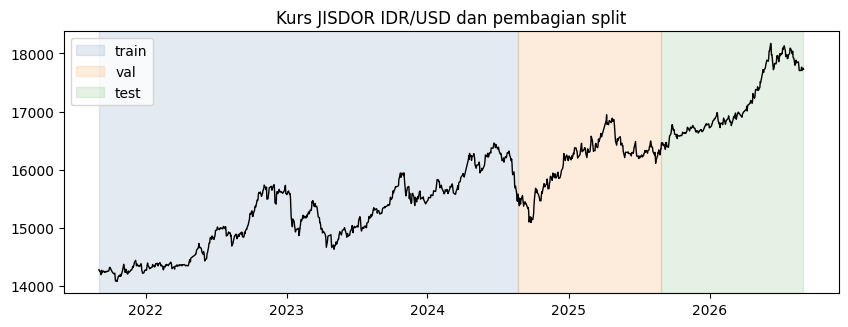

In [3]:
print(base.groupby('split', sort=False).agg(mulai=('date','min'), akhir=('date','max'), n=('y','size'), P_y1=('y','mean')).round(3))
fig, ax = plt.subplots(figsize=(10,3.4))
ax.plot(base['date'], base['kurs'], lw=1, color='k')
for s, c in zip(['train','val','test'], ['#4c78a8','#f58518','#54a24b']):
    g = base[base.split==s]; ax.axvspan(g.date.min(), g.date.max(), color=c, alpha=.15, label=s)
ax.set_title('Kurs JISDOR IDR/USD dan pembagian split'); ax.legend(); plt.show()

**Catatan**: kurs bersifat non-stasioner (tren melemah), jadi model memakai *return*, bukan level. Proporsi kelas per split berbeda (val 51%, test 57%), sehingga majority baseline harus dilaporkan per split.

In [4]:
r = base['ret_pct']
print('Autokorelasi return lag1..5:', [round(r.autocorr(k),3) for k in range(1,6)])
print('Akurasi persistence (semua hari):', round((base.y == base.y.shift(1)).mean(), 3))
print(base['ret_pct'].describe().round(3))

Autokorelasi return lag1..5: [np.float64(0.097), np.float64(-0.102), np.float64(0.016), np.float64(0.04), np.float64(-0.013)]
Akurasi persistence (semua hari): 0.516
count    1201.000
mean        0.019
std         0.333
min        -1.401
25%        -0.148
50%         0.039
75%         0.210
max         1.909
Name: ret_pct, dtype: float64


## 2. Volume berita dan kualitas teks

count    1201.0
mean       34.5
std        20.8
min         2.0
25%        26.0
50%        31.0
75%        38.0
max       403.0
dtype: float64


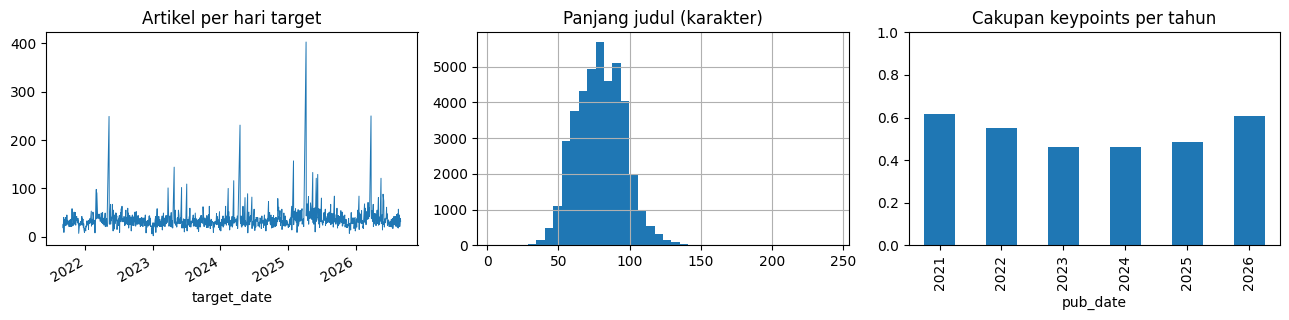

Cakupan keypoints: 0.516


In [5]:
cnt = arts.groupby('target_date').size()
print(cnt.describe().round(1))
fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
cnt.plot(ax=ax[0], lw=.7); ax[0].set_title('Artikel per hari target')
arts['text_title'].str.len().hist(bins=40, ax=ax[1]); ax[1].set_title('Panjang judul (karakter)')
arts.groupby(arts.pub_date.dt.year)['has_kp'].mean().plot.bar(ax=ax[2]); ax[2].set_title('Cakupan keypoints per tahun'); ax[2].set_ylim(0,1)
plt.tight_layout(); plt.show()
print('Cakupan keypoints:', round(arts.has_kp.mean(),3))

- Cakupan keypoints hanya ~52% dan berubah antar tahun -> keypoints dipakai sebagai **varian** (`title_kp`), bukan basis utama; judul tersedia untuk 100% artikel.
- Volume per hari punya outlier (hari dengan >100 artikel) -> fitur dinormalisasi (rata-rata/proporsi), bukan jumlah mentah.

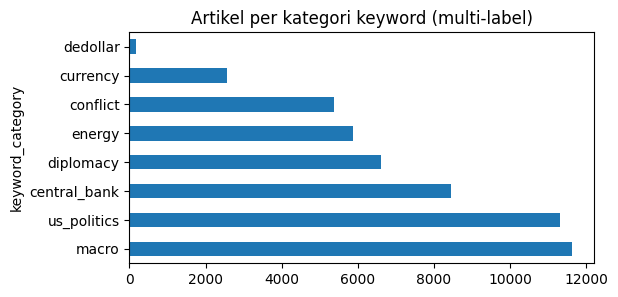

In [6]:
cats = arts['keyword_category'].fillna('').str.split('|').explode().value_counts()
cats.plot.barh(figsize=(6,3)); plt.title('Artikel per kategori keyword (multi-label)'); plt.show()

## 3. Judul vs isi (keypoints): apakah sinyal berbeda?
Bandingkan korelasi Spearman fitur sentimen harian dengan return hari target, untuk dua varian teks.

In [7]:
from scipy.stats import spearmanr
d = base.set_index('date').join(feat)
rows = []
for c in ['t_compound_mean','t_share_neg','t_lm_negative_mean','t_lm_uncertainty_mean',
          'tk_compound_mean','tk_share_neg','tk_lm_negative_mean','tk_lm_uncertainty_mean']:
    x = d[[c,'ret_pct']].dropna(); rho, p = spearmanr(x[c], x['ret_pct'])
    rows.append((c, round(rho,3), round(p,3)))
print(pd.DataFrame(rows, columns=['fitur','spearman_vs_ret_T','p_value']).to_string(index=False))

                 fitur  spearman_vs_ret_T  p_value
       t_compound_mean              0.011    0.693
           t_share_neg             -0.026    0.376
    t_lm_negative_mean             -0.077    0.008
 t_lm_uncertainty_mean             -0.042    0.148
      tk_compound_mean              0.007    0.802
          tk_share_neg             -0.022    0.437
   tk_lm_negative_mean             -0.072    0.012
tk_lm_uncertainty_mean             -0.021    0.462


In [8]:
# Redundansi antar varian: apakah tk_ (judul+keypoints) membawa info yang BEDA dari t_ (judul saja)?
# Kalau rho tinggi, keduanya sebagian besar membawa sinyal yang sama (redundan), bukan saling melengkapi.
pairs = [('t_compound_mean', 'tk_compound_mean'), ('t_share_neg', 'tk_share_neg'),
         ('t_lm_negative_mean', 'tk_lm_negative_mean'), ('t_lm_uncertainty_mean', 'tk_lm_uncertainty_mean')]
rows = []
for a, b in pairs:
    x = d[[a, b]].dropna()
    rho, p = spearmanr(x[a], x[b])
    rows.append((f'{a} vs {b}', round(rho, 3), round(p, 3)))
print(pd.DataFrame(rows, columns=['pasangan_fitur', 'rho', 'p_value']).to_string(index=False))

                                 pasangan_fitur   rho  p_value
            t_compound_mean vs tk_compound_mean 0.780      0.0
                    t_share_neg vs tk_share_neg 0.785      0.0
      t_lm_negative_mean vs tk_lm_negative_mean 0.858      0.0
t_lm_uncertainty_mean vs tk_lm_uncertainty_mean 0.834      0.0


**Kesimpulan judul vs judul+keypoints**: kedua varian (`t_` dan `tk_`) sama-sama berkorelasi lemah dengan return
hari target (rho di kisaran -0,08 sampai 0,01, sebagian besar tidak signifikan) — jadi korelasi terhadap
return **bukan** alasan untuk membuang keypoints, karena judul saja pun sama lemahnya.

Alasan sebenarnya ada di sel di atas: `t_` dan `tk_` saling berkorelasi **tinggi satu sama lain** (rho 0,78-0,86).
Ini berarti versi judul+keypoints sebagian besar membawa informasi yang **sama** dengan judul, bukan sinyal
tambahan yang berbeda — jadi menambahkannya sebagai fitur terpisah kemungkinan besar hanya menambah
redundansi, bukan informasi baru. Digabung dengan cakupan keypoints yang tidak lengkap (~52% artikel,
bervariasi 46-62% antar tahun, lihat bagian 2 di atas), keypoints tidak dipakai sebagai fitur model dan
hanya dipertahankan di notebook ini untuk perbandingan deskriptif.

Korelasi hampir nol untuk sebagian besar fitur. Satu-satunya yang nominal signifikan adalah proporsi kata negatif Loughran-McDonald (rho sekitar -0,08, p sekitar 0,01 pada kedua varian). Itu tidak bertahan koreksi Bonferroni untuk 8 uji (alpha = 0,006) dan bertanda berlawanan dengan intuisi (lebih banyak kata negatif, kurs cenderung turun). Jadi tidak ada bukti sinyal linear yang kuat dan stabil.

## 4. Sensitivitas lag (pembenaran pergeseran target)
Korelasi Spearman sentimen bucket-T dengan return pada T+k (k=0 adalah desain kami: berita terbit sebelum T, return hari T). Ini pemeriksaan deskriptif; alasan utama pergeseran target bersifat a priori (tanggal CNBC memakai waktu AS dan tidak ada jam terbit).

In [9]:
rows = []
for c in ['t_compound_mean','t_share_neg','t_lm_negative_mean']:
    for k in range(-2, 3):
        x = pd.DataFrame({'f': d[c], 'r': d['ret_pct'].shift(-k)}).dropna()
        rows.append((c, k, round(spearmanr(x.f, x.r)[0], 3)))
lag = pd.DataFrame(rows, columns=['fitur','k','rho']).pivot(index='fitur', columns='k', values='rho')
print(lag.to_string())

k                      -2     -1      0      1      2
fitur                                                
t_compound_mean    -0.008 -0.035  0.011  0.029  0.028
t_lm_negative_mean  0.014 -0.010 -0.077 -0.029 -0.009
t_share_neg         0.019  0.011 -0.026 -0.010 -0.019


Korelasi terbesar hanya muncul di k=0 untuk `t_lm_negative_mean` (-0,077); pola di lag lain mendekati nol. Tidak ada indikasi fitur bucket-T lebih informatif untuk hari lain.

## 5. Kata paling membedakan hari IDR melemah vs tidak (train saja)

In [10]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
docs = arts.groupby('target_date')['clean_title'].apply(lambda s: ' '.join(s.fillna(''))).rename('doc')
tr = base[base.split=='train'].set_index('date').join(docs)
vec = TfidfVectorizer(ngram_range=(1,1), min_df=5, max_df=.8, sublinear_tf=True)
X = vec.fit_transform(tr['doc'])
mu1 = np.asarray(X[tr.y.values==1].mean(0)).ravel(); mu0 = np.asarray(X[tr.y.values==0].mean(0)).ravel()
terms = np.array(vec.get_feature_names_out()); diff = mu1 - mu0
o = np.argsort(diff)
print('Lebih khas hari IDR melemah :', ', '.join(terms[o[::-1][:15]]))
print('Lebih khas hari tidak melemah:', ', '.join(terms[o[:15]]))

Lebih khas hari IDR melemah : strong, upside, plant, head, investor, disruption, strike, asian, consider, taiwan, equity, air, see, growth, behind
Lebih khas hari tidak melemah: better, stay, report, return, health, cooler, crude, could, payroll, elon, announces, water, started, job, fall


Perbedaan bobot sangat kecil dan didominasi kata topikal umum; ini deskriptif (bukan bukti kausal) dan menjelaskan mengapa TF-IDF tidak memberi keunggulan pada model.